# Anomaly Detection in Transactions — 02 Data Cleaning & Scaling

The ULB dataset is already clean (no missing values; `V1`–`V28` are PCA outputs). The one necessary step is **standardisation**: `Time` and `Amount` live on completely different scales to the PCA features, and the distance- / margin-based detectors (LOF, One-Class SVM) are scale-sensitive. We StandardScaler every feature and save a cleaned CSV for notebook 03.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import utils

df = utils.load_data()
print('shape:', df.shape)

shape: (20492, 31)


## 1. Missing values & duplicates

In [2]:
print('missing values per column (max):', df.isnull().sum().max())
print('duplicate rows:', df.duplicated().sum())

missing values per column (max): 0
duplicate rows: 25


## 2. Why scaling is needed

Compare the spread of `Amount`/`Time` against a PCA feature — orders of magnitude apart.

In [3]:
print(df[['Time','Amount','V1','V2']].describe().loc[['mean','std','min','max']].round(2))

           Time   Amount     V1     V2
mean   94812.92    87.19  -0.11   0.09
std    47591.15   222.53   2.28   1.80
min        0.00     0.00 -32.06 -48.06
max   172787.00  5627.06   2.40  22.06


## 3. Standardise all features

`utils.preprocess` returns the scaled matrix, the labels (for later evaluation only), and the fitted scaler.

In [4]:
X_scaled, y, scaler, feat_cols = utils.preprocess(df)
print('scaled matrix:', X_scaled.shape)
scaled_df = pd.DataFrame(X_scaled, columns=feat_cols)
print('after scaling — mean ~0, std ~1:')
print(scaled_df[['Time','Amount','V1']].describe().loc[['mean','std']].round(3))

scaled matrix: (20492, 30)
after scaling — mean ~0, std ~1:
      Time  Amount   V1
mean  -0.0    -0.0 -0.0
std    1.0     1.0  1.0


## 4. Before/after: Amount

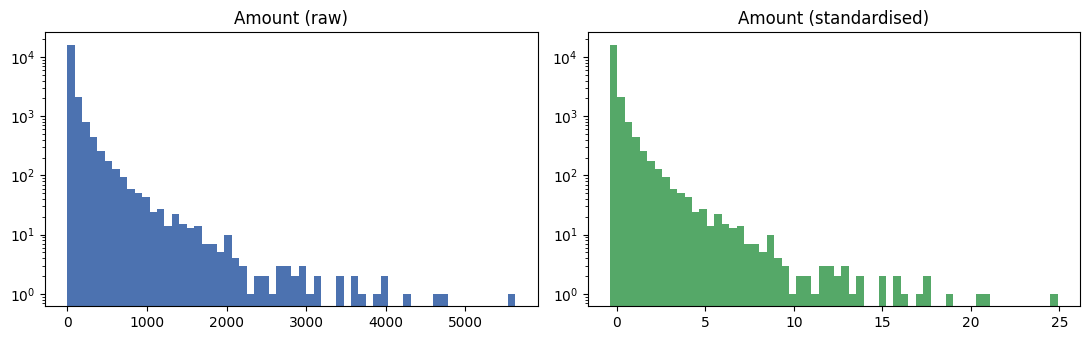

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['Amount'], bins=60, color='#4c72b0'); ax[0].set_title('Amount (raw)'); ax[0].set_yscale('log')
ax[1].hist(scaled_df['Amount'], bins=60, color='#55a868'); ax[1].set_title('Amount (standardised)'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()

## 5. Save cleaned dataset

In [6]:
cleaned = scaled_df.copy()
cleaned['Class'] = y
cleaned.to_csv('data/creditcard_cleaned.csv', index=False)
print('saved data/creditcard_cleaned.csv', cleaned.shape)
print('no missing:', cleaned.isnull().sum().max() == 0)

saved data/creditcard_cleaned.csv (20492, 31)
no missing: True
